# Quebec Winter Tire Fulfillment Gap — Analysis

**Scenario:** Sales reps in Quebec report losing garage customers ahead of winter tire season, claiming orders couldn't be fulfilled in time. This notebook works through confirming whether that's true, benchmarking it against other regions, ruling out simpler explanations, quantifying the business impact, and tracing it to a root cause.

**Approach:** confirm it's real -> benchmark against other regions -> rule out the easy explanation -> quantify impact -> find the mechanism.

## Setup

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)

DB_PATH = '../data/tire_distributor.db'  # adjust if running outside the repo structure
conn = sqlite3.connect(DB_PATH)

def q(sql, params=None):
    """Run a SQL query against the database and return a DataFrame."""
    return pd.read_sql_query(sql, conn, params=params)

print('Connected. Tables available:')
print(q("SELECT name FROM sqlite_master WHERE type='table'"))


Connected. Tables available:
                  name
0           warehouses
1             products
2           sales_reps
3            customers
4  inventory_snapshots
5               orders
6          order_items


## Quick schema peek

In [2]:
for t in ['warehouses','products','sales_reps','customers','orders','order_items','inventory_snapshots']:
    print(f'--- {t} ---')
    display(q(f'SELECT * FROM {t} LIMIT 3'))

--- warehouses ---


,warehouse_id,name,city,province
0,1,Northline Vancouver DC,Vancouver,BC
1,2,Northline Calgary DC,Calgary,AB
2,3,Northline Toronto DC,Toronto,ON


--- products ---


,product_id,sku,brand,model,tire_type,size,cost,list_price
0,1,SKU-0001,Michelin,Michelin WeatherGrip2,Winter,245/40R19,68.92,108.37
1,2,SKU-0002,Michelin,Michelin Defender5,Winter,215/60R16,147.06,228.39
2,3,SKU-0003,Michelin,Michelin WeatherGrip5,Summer,235/55R18,58.97,81.27


--- sales_reps ---


...

,order_id,customer_id,warehouse_id,rep_id,order_date,status
0,1,87,3,9,2024-01-01,Cancelled
1,2,32,1,2,2024-01-01,Fulfilled
2,3,50,2,5,2024-01-01,Fulfilled


--- order_items ---


,order_item_id,order_id,product_id,quantity_ordered,quantity_fulfilled,unit_price
0,1,1,49,4,0,156.60
1,2,2,40,20,20,221.78
2,3,3,21,16,16,186.34


--- inventory_snapshots ---


,snapshot_date,warehouse_id,product_id,quantity_on_hand,reorder_point
0,2024-01-01,1,1,132,30
1,2024-01-01,1,2,101,30
2,2024-01-01,1,3,139,30


## 1. Is it happening?

First pass: look at Quebec's order status counts over time, before narrowing to any specific tire type or comparing against other regions.

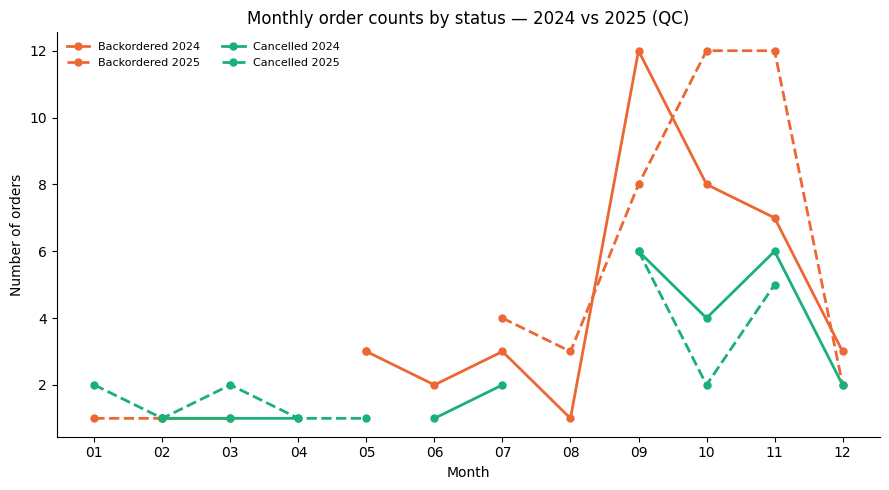

In [3]:
### count orders by status per month, 2024 vs 2025
import matplotlib.pyplot as plt

monthly= q("""
SELECT
  strftime('%Y', orders.order_date) AS year,
  strftime('%m', orders.order_date) AS month,
  orders.status,
  COUNT(*) AS n_orders
FROM orders
JOIN CUSTOMERS ON orders.customer_id = customers.customer_id 
WHERE strftime('%Y', orders.order_date) IN ('2024', '2025') 
AND orders.STATUS IN ('Backordered', 'Cancelled') 
AND customers.PROVINCE ='QC'
group by year, month, status
ORDER BY month, year, status
""")


month_order = [f'{m:02d}' for m in range(1, 13)]

status_colors = {
    'Backordered': '#eb6834',
    'Cancelled': '#1baf7a',
}
year_styles = {'2024': '-', '2025': '--'}

fig, ax = plt.subplots(figsize=(9, 5))
for status, color in status_colors.items():
    for year, style in year_styles.items():
        sub = (monthly[(monthly['status'] == status) & (monthly['year'] == year)]
               .set_index('month')
               .reindex(month_order)['n_orders'])
        ax.plot(month_order, sub.values, color=color, linestyle=style, linewidth=2,
                marker='o', markersize=5, label=f'{status} {year}')

ax.set_xlabel('Month')
ax.set_ylabel('Number of orders')
ax.set_title('Monthly order counts by status — 2024 vs 2025 (QC)')
ax.legend(ncol=2, fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()



**Observation:** backorders and cancellations both spike in Sep-Nov, in both 2024 and 2025. Worth checking whether this holds across all provinces or is specific to Quebec.

## 2. How bad, and where

First pass across all tire types, comparing every province:

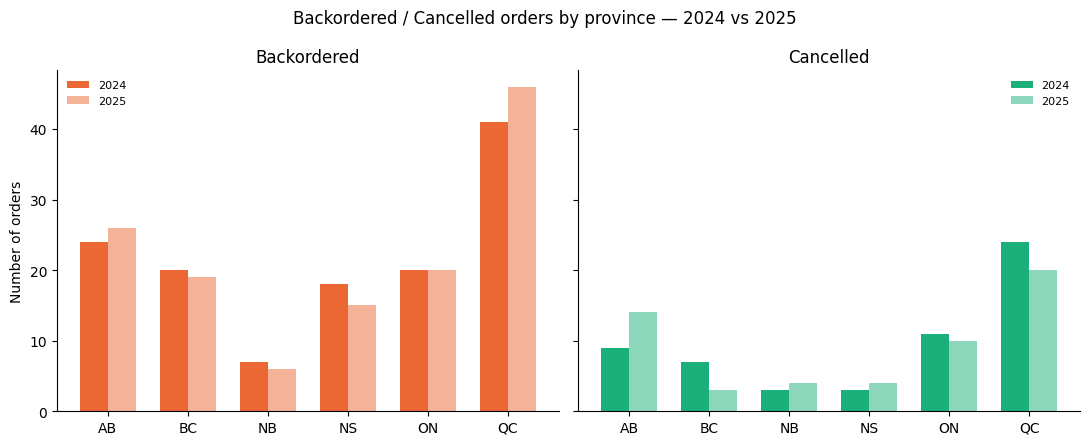

In [4]:
### total Backordered/Cancelled orders by province, 2024 vs 2025
import numpy as np

by_province = q("""
SELECT
  customers.province,
  strftime('%Y', orders.order_date) AS year,
  orders.status,
  COUNT(*) AS n_orders
FROM orders
JOIN customers ON orders.customer_id = customers.customer_id
WHERE strftime('%Y', orders.order_date) IN ('2024', '2025')
  AND orders.status IN ('Backordered', 'Cancelled')
GROUP BY province, year, status
ORDER BY province, year, status
""")

provinces = sorted(by_province['province'].unique())
x = np.arange(len(provinces))
width = 0.35

status_colors = {'Backordered': '#eb6834', 'Cancelled': '#1baf7a'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (status, color) in zip(axes, status_colors.items()):
    sub = by_province[by_province['status'] == status]
    counts_2024 = sub[sub['year'] == '2024'].set_index('province').reindex(provinces)['n_orders'].fillna(0)
    counts_2025 = sub[sub['year'] == '2025'].set_index('province').reindex(provinces)['n_orders'].fillna(0)

    ax.bar(x - width/2, counts_2024, width, color=color, alpha=1.0, label='2024')
    ax.bar(x + width/2, counts_2025, width, color=color, alpha=0.5, label='2025')

    ax.set_title(status)
    ax.set_xticks(x)
    ax.set_xticklabels(provinces)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel('Number of orders')
fig.suptitle('Backordered / Cancelled orders by province — 2024 vs 2025')
plt.tight_layout()
plt.show()

### Refining to winter tires specifically

The complaint was specifically about winter tires, and mixing in all tire types could understate (or misrepresent) the effect. Re-running scoped to winter tires only:

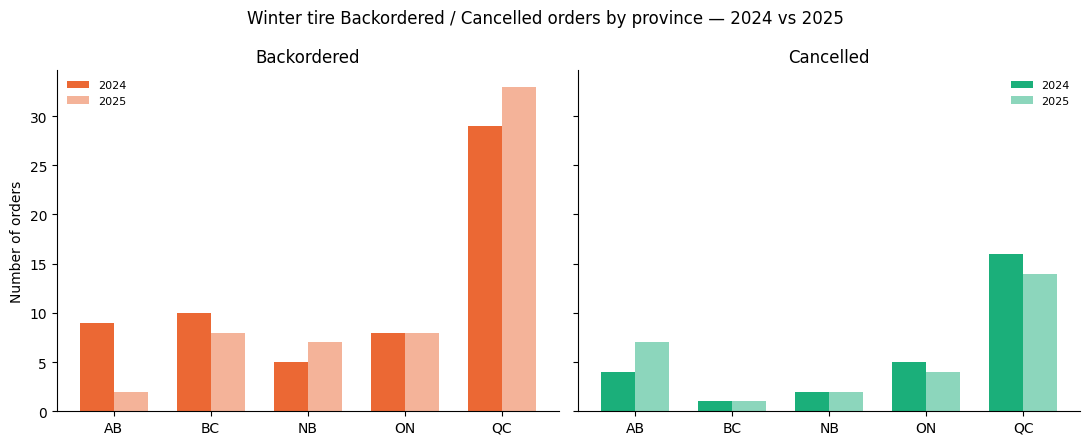

In [5]:

### Winter tire Backordered/Cancelled orders by province, 2024 vs 2025
import numpy as np
import matplotlib.pyplot as plt

winter_by_province = q("""
SELECT
  w.province,
  strftime('%Y', o.order_date) AS year,
  o.status,
  COUNT(DISTINCT o.order_id) AS n_orders
FROM orders o
JOIN order_items io ON o.order_id = io.order_id
JOIN products p ON io.product_id = p.product_id
JOIN warehouses w ON o.warehouse_id = w.warehouse_id
WHERE o.status IN ('Backordered', 'Cancelled')
  AND p.tire_type = 'Winter'
  AND strftime('%Y', o.order_date) IN ('2024', '2025')
GROUP BY w.province, year, o.status
ORDER BY w.province, year, o.status
""")

provinces = sorted(winter_by_province['province'].unique())
x = np.arange(len(provinces))
width = 0.35

status_colors = {'Backordered': '#eb6834', 'Cancelled': '#1baf7a'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (status, color) in zip(axes, status_colors.items()):
    sub = winter_by_province[winter_by_province['status'] == status]
    counts_2024 = sub[sub['year'] == '2024'].set_index('province').reindex(provinces)['n_orders'].fillna(0)
    counts_2025 = sub[sub['year'] == '2025'].set_index('province').reindex(provinces)['n_orders'].fillna(0)

    ax.bar(x - width/2, counts_2024, width, color=color, alpha=1.0, label='2024')
    ax.bar(x + width/2, counts_2025, width, color=color, alpha=0.5, label='2025')

    ax.set_title(status)
    ax.set_xticks(x)
    ax.set_xticklabels(provinces)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel('Number of orders')
fig.suptitle('Winter tire Backordered / Cancelled orders by province — 2024 vs 2025')
plt.tight_layout()
plt.show()

**Finding:** Quebec is a clear outlier on both backorders and cancellations, in both years, once scoped to winter tires.

## 3. Ruling out the easy explanation

Before trusting that gap, check whether Quebec simply has more order volume overall — that alone could make raw counts look worse without the underlying rate actually being different.

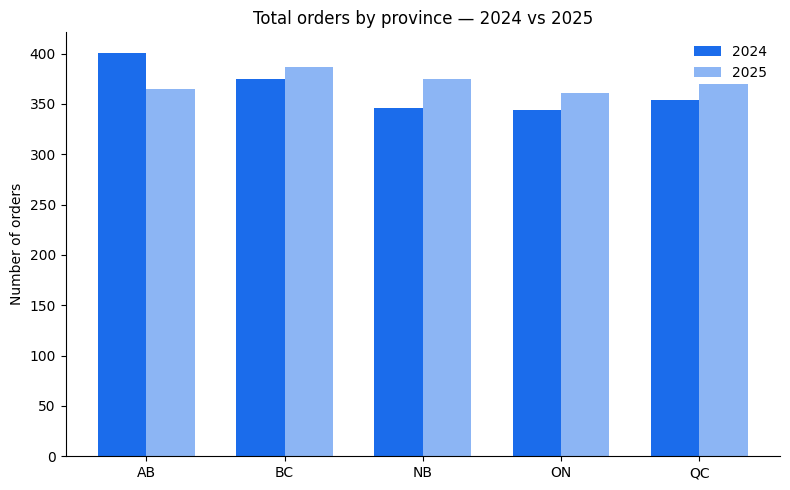

In [6]:
### total orders by province, 2024 vs 2025
import numpy as np
import matplotlib.pyplot as plt

orders_by_province = q("""
SELECT
  w.province,
  strftime('%Y', o.order_date) AS year,
  COUNT(*) AS n_orders
FROM orders o
JOIN warehouses w ON o.warehouse_id = w.warehouse_id
WHERE strftime('%Y', o.order_date) IN ('2024', '2025')
GROUP BY w.province, year
ORDER BY w.province, year
""")

provinces = sorted(orders_by_province['province'].unique())
x = np.arange(len(provinces))
width = 0.35

color = '#1b6ceb'
counts_2024 = (orders_by_province[orders_by_province['year'] == '2024']
               .set_index('province').reindex(provinces)['n_orders'].fillna(0))
counts_2025 = (orders_by_province[orders_by_province['year'] == '2025']
               .set_index('province').reindex(provinces)['n_orders'].fillna(0))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, counts_2024, width, color=color, alpha=1.0, label='2024')
ax.bar(x + width/2, counts_2025, width, color=color, alpha=0.5, label='2025')

ax.set_xticks(x)
ax.set_xticklabels(provinces)
ax.set_ylabel('Number of orders')
ax.set_title('Total orders by province — 2024 vs 2025')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Finding:** order volume is roughly even across provinces. This rules out volume as the explanation — the gap is a fulfillment issue, not a byproduct of Quebec generating more orders.

## 4. Sizing it properly: backorder rate by province

Raw counts aren't comparable across provinces of different sizes. Converting to a rate (backordered / total winter tire orders) puts every province on the same footing:

In [7]:
q("""
SELECT
  w.province,
  SUM(CASE WHEN status = 'Backordered' THEN 1 ELSE 0 END) AS n_backordered,
  COUNT(*) AS n_total,
  1.0 * SUM(CASE WHEN status = 'Backordered' THEN 1 ELSE 0 END) / COUNT(*) AS backorder_rate
FROM orders
JOIN warehouses w ON orders.warehouse_id = w.warehouse_id
JOIN ORDER_ITEMS io ON orders.order_id = io.order_id
JOIN PRODUCTS p ON io.product_id = p.product_id
WHERE p.tire_type = 'Winter'
GROUP BY w.province
ORDER BY w.province
""")


,province,n_backordered,n_total,backorder_rate
0,AB,11,255,0.043137
1,BC,22,272,0.080882
2,NB,13,228,0.057018
3,ON,16,258,0.062016
4,QC,70,242,0.289256


**Finding:** Quebec's winter tire backorder rate is roughly 4-7x every other province. This is the number that confirms the complaint isn't anecdotal.

## 5. Finding the mechanism: inventory

Checking whether this is a supply-side (stock) problem. First, Quebec's winter tire inventory on its own:

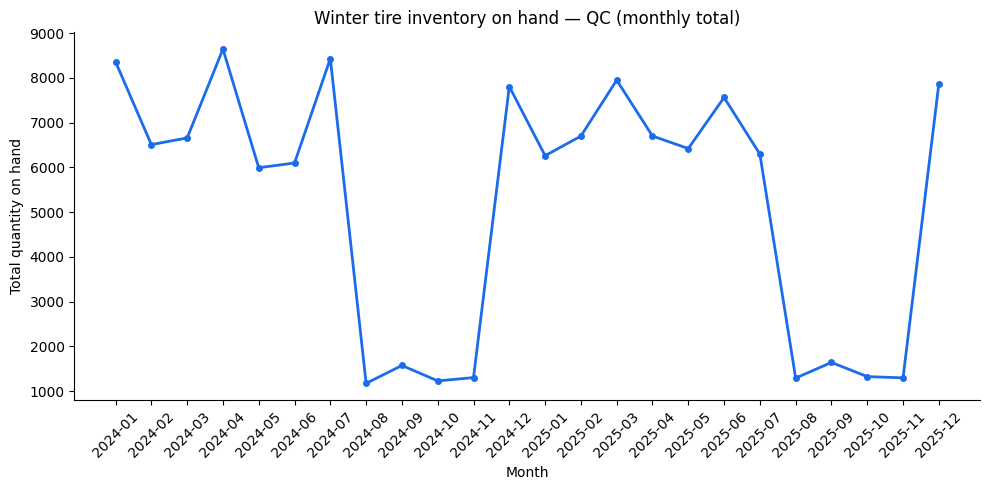

In [8]:
df = q("""
SELECT
  strftime('%Y-%m', ins.snapshot_date) AS month,
  sum(ins.quantity_on_hand) AS total_quantity
FROM inventory_snapshots ins
JOIN products p ON ins.product_id = p.product_id
JOIN warehouses w ON ins.warehouse_id = w.warehouse_id
WHERE p.tire_type = 'Winter' AND w.province = 'QC'
GROUP BY month
ORDER BY month
""")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['month'], df['total_quantity'], color='#1b6ceb', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Month')
ax.set_ylabel('Total quantity on hand')
ax.set_title('Winter tire inventory on hand — QC (monthly total)')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Quebec's stock collapses for several months a year. Before concluding this is Quebec-specific, compare against every other province on the same chart:

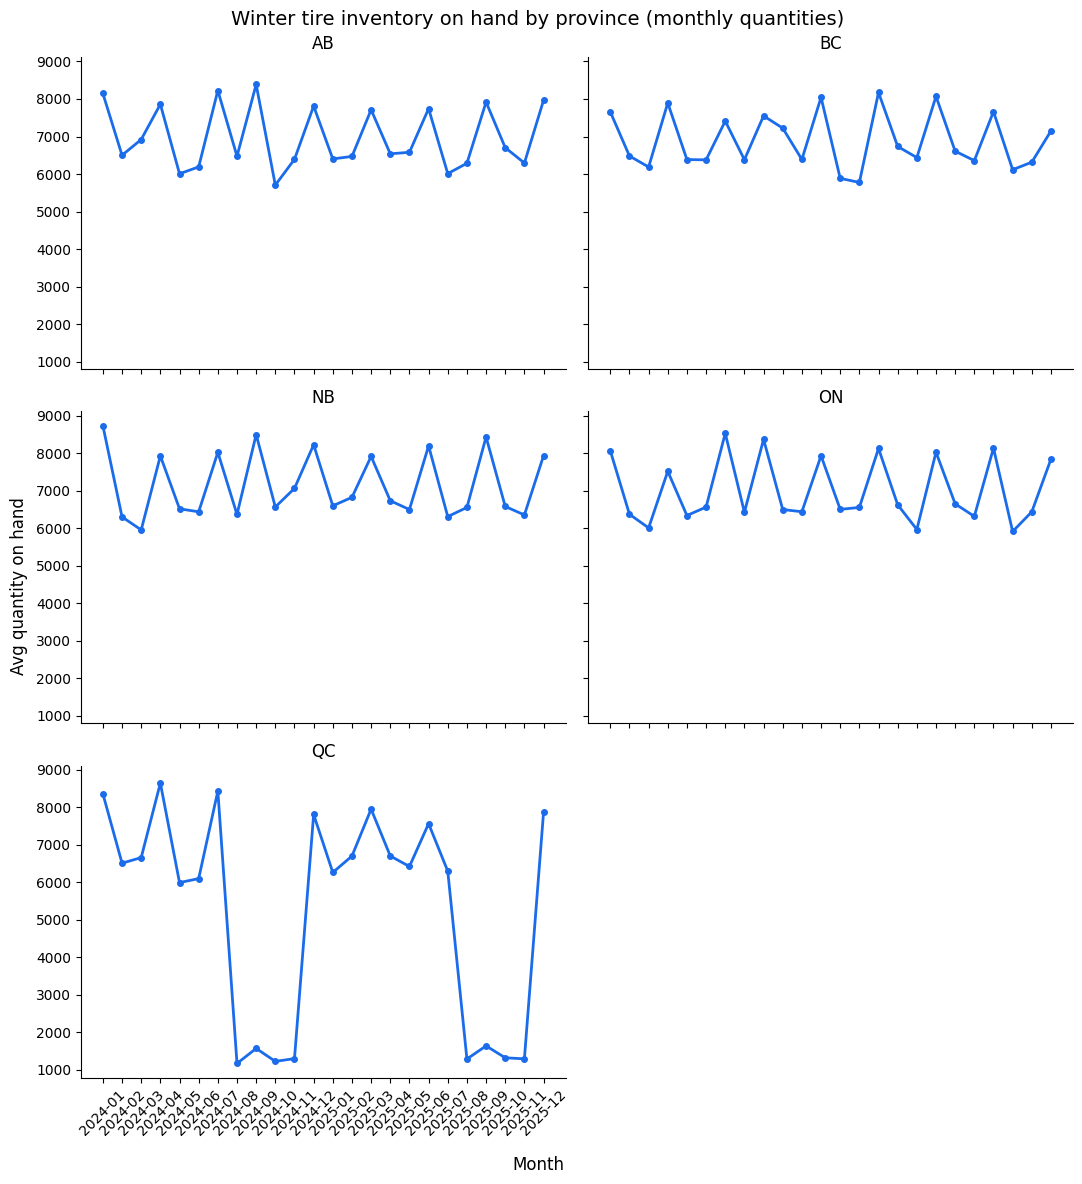

In [9]:
df = q("""
SELECT
  w.province,
  strftime('%Y-%m', ins.snapshot_date) AS month,
  sum(ins.quantity_on_hand) AS sum_quantity
FROM inventory_snapshots ins
JOIN products p ON ins.product_id = p.product_id
JOIN warehouses w ON ins.warehouse_id = w.warehouse_id
WHERE p.tire_type = 'Winter'
GROUP BY w.province, month
ORDER BY w.province, month
""")

provinces = sorted(df['province'].unique())
ncols = 2
nrows = -(-len(provinces) // ncols)  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 4 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for ax, province in zip(axes, provinces):
    sub = df[df['province'] == province]
    ax.plot(sub['month'], sub['sum_quantity'], color="#1b6ceb", linewidth=2, marker='o', markersize=4)
    ax.set_title(province)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(provinces):]:
    ax.set_visible(False)

fig.suptitle('Winter tire inventory on hand by province (monthly quantities)', fontsize=14)
fig.supxlabel('Month')
fig.supylabel('Avg quantity on hand')
plt.tight_layout()
plt.show()

**Finding:** Quebec is the only province where winter tire stock collapses for four consecutive months (Aug-Nov) each year, while every other province fluctuates mildly year-round. This inventory timing gap is the root cause of Quebec's elevated backorder rate.

## 6. Quantifying the business impact

Order counts and rates don't tell leadership how much this costs. Pricing out the unfulfilled quantity turns this into a dollar figure, tracked by month:

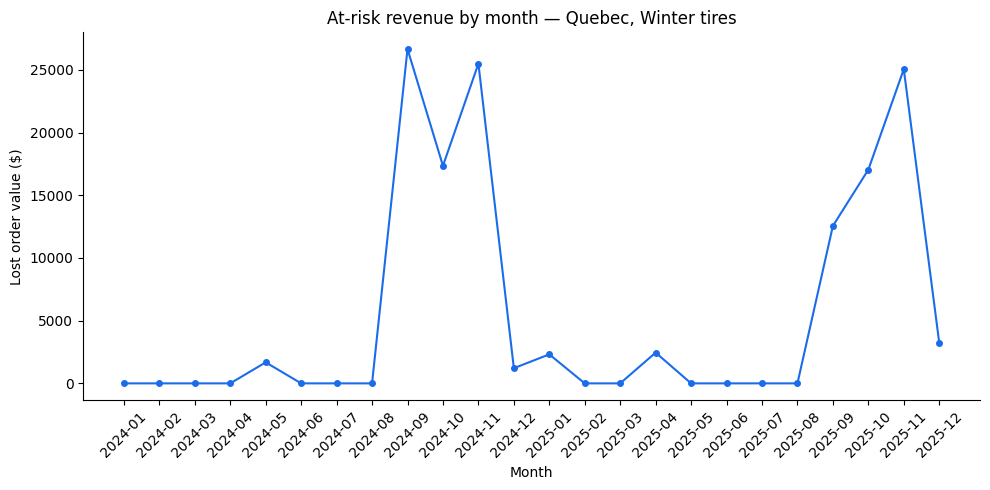

In [10]:
df = q("""
SELECT
  strftime('%Y-%m', o.order_date) AS month,
  SUM(oi.unit_price * (oi.quantity_ordered - oi.quantity_fulfilled)) AS total_order_lost,
  p.tire_type
FROM order_items AS oi
JOIN orders AS o ON oi.order_id = o.order_id
JOIN products AS p ON oi.product_id = p.product_id
WHERE oi.quantity_fulfilled < oi.quantity_ordered
  AND o.warehouse_id = 4
  AND p.tire_type = 'Winter'
GROUP BY month
ORDER BY month
""")

# Pin the range explicitly (2024-01 through 2025-12) rather than using
# df['month'].min()/max() -- since months with zero at-risk revenue don't
# appear in the query result at all, reindexing off the data's own min/max
# would silently drop quiet months at the start/end instead of showing them as 0.
all_months = pd.date_range('2024-01-01', '2025-12-01', freq='MS').strftime('%Y-%m')
s = df.set_index('month')['total_order_lost'].reindex(all_months).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(s.index, s.values, color='#1b6ceb', marker='o', markersize=4)
ax.set_xlabel('Month')
ax.set_ylabel('Lost order value ($)')
ax.set_title('At-risk revenue by month — Quebec, Winter tires')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The pattern repeats in both years and is concentrated almost entirely in Sep-Nov. Rolling it up into a single headline figure for that window:

In [11]:
q("""
SELECT
    SUM((oi.quantity_ordered - oi.quantity_fulfilled) * oi.unit_price) AS at_risk_revenue,
    SUM(oi.quantity_ordered - oi.quantity_fulfilled) AS units_short,
    COUNT(DISTINCT o.order_id) AS affected_orders
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN warehouses w ON o.warehouse_id = w.warehouse_id
WHERE w.province = 'QC' 
  AND p.tire_type = 'Winter'
  AND strftime('%m', o.order_date) IN ('09','10','11')
  AND oi.quantity_fulfilled < oi.quantity_ordered
""")

,at_risk_revenue,units_short,affected_orders
0,124168.8,738,87


**Finding:** ~$124,169 in at-risk revenue, 738 units short, across 87 affected orders — Quebec winter tires, Sep-Nov. (Aug and Dec were checked separately; together they added under 4% to the two-year total, so the window was kept to Sep-Nov for consistency with the rest of the analysis.)

This is a floor, not a ceiling — it only counts orders that were placed and partially unfulfilled. It doesn't capture demand that went straight to a competitor without ever becoming an order here.

See `../report/Quebec_Winter_Tire_Report.docx` for the full write-up, recommendations, and limitations.